Determine retrievability of TLogic compliant patterns from synthetic TKGs using TLogic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from collections import defaultdict
from itertools import combinations, combinations_with_replacement, product, permutations

import os
import random
import re

# Utilities

## Handle TLogic mined rules

In [2]:
# def extract_triple(s):
#     match = re.match(r'(.+?)\((X\d),\s*(X\d),\s*T\d+\)', s)
#     if not match:
#         raise ValueError(f"Could not parse triple: {s}")
#     rel, h, t = match.groups()
#     return (h, rel.strip(), t)

def extract_triple(s):
    m = re.match(r'^\s*([^\(]+?)\s*\((X\d),\s*(X\d),\s*T\d+\)\s*$', s)
    if not m:
        raise ValueError(f"Could not parse triple: {s}")
    rel, h, t = m.groups()
    rel = re.sub(r'^[,\s]+', '', rel.strip())
    return (h, rel, t)

In [3]:
def normalize_relation(triple):
    # Normalize TLogic's inverse relations by flipping entity order and uninverting relation
    h, r, t = triple
    if r.startswith('_'):
        return (t, r[1:], h)
    return (h, r, t)

In [4]:
# def load_mined_rules(file_path):
#     rules = []
#     triple_pattern = re.compile(r'(.+?)\((X\d),\s*(X\d),\s*T\d+\)')

#     with open(file_path, 'r') as f:
#         for line in f:
#             if '<-' not in line:
#                 continue
#             parts = line.strip().split(maxsplit=3)
#             if len(parts) != 4:
#                 continue
#             conf, count, support, rule_str = parts
#             try:
#                 head_str, body_str = rule_str.split(' <- ')
#                 head = extract_triple(head_str)
#                 body_matches = triple_pattern.findall(body_str)
#                 body = [(h, rel.strip(), t) for rel, h, t in body_matches]
#                 rules.append({
#                     'confidence': float(conf),
#                     'count': int(count),
#                     'support': int(support),
#                     'head': head,
#                     'body': body,
#                     'n_hops': len(body)
#                 })
#             except Exception as e:
#                 print(f"Skipping rule due to parse error: {e}\n{line}")

#     return rules

def load_mined_rules(file_path):
    """
    Parse TLogic mined rules file (confidence, count, support, 'Head <- body, body, ...').
    Crucial fix: in the body, skip the delimiter ', ' before each triple so it doesn't leak
    into the relation token.
    """
    rules = []
    triple_pattern = re.compile(r'(?:^|,\s*)(.+?)\((X\d),\s*(X\d),\s*T\d+\)')

    with open(file_path, 'r') as f:
        for line in f:
            if '<-' not in line:
                continue
            parts = line.strip().split(maxsplit=3)
            if len(parts) != 4:
                continue
            conf, count, support, rule_str = parts
            try:
                head_str, body_str = rule_str.split(' <- ')
                head = extract_triple(head_str)

                body_matches = triple_pattern.findall(body_str)
                body = []
                for rel, h, t in body_matches:
                    rel = re.sub(r'^[,\s]+', '', rel.strip())
                    body.append((h, rel, t))

                rules.append({
                    'confidence': float(conf),
                    'count': int(count),
                    'support': int(support),
                    'head': head,
                    'body': body,
                    'n_hops': len(body)
                })
            except Exception as e:
                print(f"Skipping rule due to parse error: {e}\n{line}")

    return rules

## Handle synthetic TKG patterns

In [5]:
def load_ground_truth_patterns(file_path):
    gt_patterns = []
    triple_pattern = re.compile(r'\((e\d),\s*(\d+),\s*(e\d),\s*t\d+(?:=.*?)?\)')

    with open(file_path, 'r') as f:
        for line in f:
            if '->' not in line:
                continue
            try:
                rule_part, n_hops, rule_id = line.strip().split('\t')
                body_str, head_str = rule_part.split(' -> ')
                body_matches = triple_pattern.findall(body_str)
                head_match = triple_pattern.findall(head_str)

                if not body_matches or not head_match:
                    continue

                body = [(h, r, t) for h, r, t in body_matches]
                head = head_match[0]
                pattern = canonicalize_pattern(body, head)

                gt_patterns.append({
                    'id': int(rule_id),
                    'n_hops': int(n_hops),
                    'canonical_pattern': pattern,
                    'raw_line': line.strip(),
                    'match_found': False,
                    'matched_rule': None
                })
            except Exception as e:
                print(f"Skipping GT pattern due to parse error: {e}\n{line}")

    return gt_patterns

In [6]:
def load_triples(file_path):
    triples = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 4:
                continue
            h, r, t, ts = parts
            triples.append((h, r, t, ts))
    return triples

In [7]:
def extract_instantiated_patterns(triples):
    """Build a lookup of relation triples indexed by time for efficient pattern matching."""
    rel_by_time = defaultdict(list)
    for h, r, t, ts in triples:
        rel_by_time[int(ts)].append((h, r, t))
    return rel_by_time

In [8]:
def count_gt_pattern_instances(gt_patterns, triple_files):
    all_triples = []
    for path in triple_files:
        all_triples += load_triples(path)

    rel_by_time = extract_instantiated_patterns(all_triples)

    # Placeholder counts, real logic involves replaying patterns over time
    for gt in gt_patterns:
        gt['gt_count'] = -1  # placeholder
        gt['gt_support'] = -1  # placeholder

    return gt_patterns

In [9]:
def compute_gt_counts_from_labels(gt_patterns, triple_files):
    from ast import literal_eval

    # Fast lookup of GT pattern IDs
    gt_pattern_ids = set(p['id'] for p in gt_patterns)
    consequence_tracker = defaultdict(set)

    # Updated regex to match both antecedent and consequence labels, but only process '_c_' ones
    pattern_label_re = re.compile(r"(\d+)_([ac]\d?)_((?:e\d=\d+\|?)+)")

    for file_path in triple_files:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) < 6:
                    continue  # Malformed line

                h, r, t, ts, _, label_str = parts

                try:
                    pattern_labels = literal_eval(label_str)
                    for label in pattern_labels:
                        match = pattern_label_re.match(label)
                        if not match:
                            continue

                        pattern_id = int(match.group(1))
                        role = match.group(2)
                        bindings_str = match.group(3)

                        # Only count consequences
                        if not role.startswith('c'):
                            continue
                        if pattern_id not in gt_pattern_ids:
                            continue

                        bindings = dict(pair.split('=') for pair in bindings_str.split('|'))
                        key = tuple(sorted(bindings.items())) + (ts,)

                        consequence_tracker[pattern_id].add(key)

                except Exception as e:
                    print(f"Warning: failed to parse label: {label_str}\n{e}")
                    continue

    # Assign counts to GT pattern objects
    for gt in gt_patterns:
        pid = gt['id']
        gt['gt_count'] = len(consequence_tracker.get(pid, set()))
        gt['gt_support'] = None  # Not computed yet

    return gt_patterns

## Analysis/comparison utilities

In [10]:
def canonicalize_pattern(body, head):
    pattern = [normalize_relation(t) for t in body + [head]]
    ent_map = {}
    ent_counter = 1
    canonical = []
    for h, r, t in pattern:
        for e in (h, t):
            if e not in ent_map:
                ent_map[e] = f"e{ent_counter}"
                ent_counter += 1
        canonical.append((ent_map[h], r, ent_map[t]))
    return canonical

In [11]:
def patterns_match(p1, p2):
    # Preserve temporal pattern ordering
    if len(p1) != len(p2):
        return False
    return all(a == b for a, b in zip(p1, p2))

In [12]:
def match_mined_to_gt(gt_patterns, mined_rules):
    for gt in gt_patterns:
        for rule in mined_rules:
            canon_mined = canonicalize_pattern(rule['body'], rule['head'])
            if patterns_match(gt['canonical_pattern'], canon_mined):
                gt['match_found'] = True
                gt['matched_rule'] = rule
                break  # Stop at first match, should be impossible to get multiple matches
    return gt_patterns

In [13]:
def print_retrievability_report(gt_patterns, verbose: bool = False):
    total = len(gt_patterns)
    matched = sum(1 for p in gt_patterns if p['match_found'])
    if verbose:
        print(f"Retrieved {matched}/{total} patterns ({matched/total:.1%})\n")

    for p in gt_patterns:
        if verbose:
            print(f"Pattern ID {p['id']}: {'Found' if p['match_found'] else 'Not found'}")
        if p['match_found']:
            r = p['matched_rule']
            if verbose:
                print(f"\tConf: {r['confidence']}, Count: {r['count']}, Support: {r['support']}")

In [14]:
def run_retrievability_eval(mined_rules_path, gt_patterns_path, verbose: bool = False):
    if verbose: print("Loading mined rules...")
    mined_rules = load_mined_rules(mined_rules_path)

    if verbose: print("Loading ground-truth patterns...")
    gt_patterns = load_ground_truth_patterns(gt_patterns_path)

    if verbose: print("Matching...")
    gt_patterns = match_mined_to_gt(gt_patterns, mined_rules)

    if verbose: print("Results:")
    print_retrievability_report(gt_patterns, verbose)

    return mined_rules, gt_patterns

In [15]:
def canonical_to_key(canon_pattern):
    """Turn a canonical pattern [(e?, r, e?), ...] into a stable readable key."""
    if not canon_pattern:
        return ""
    body = canon_pattern[:-1]
    head = canon_pattern[-1]
    body_str = " & ".join([f"{h}-{r}-{t}" for (h, r, t) in body])
    head_str = f"{head[0]}-{head[1]}-{head[2]}"
    return f"{body_str} -> {head_str}"

In [16]:
def mined_rules_to_canonical_df(mined_rules):
    """Canonicalize mined rules and aggregate duplicates (same canonical_key & n_hops)."""
    rows = []
    for r in mined_rules:
        canon = canonicalize_pattern(r['body'], r['head'])
        key = canonical_to_key(canon)
        rows.append({
            'canonical_key': key,
            'n_hops': r['n_hops'],
            'confidence': r['confidence'],
            'count': r['count'],
            'support': r['support']
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Aggregate: take max confidence (strongest rule), sum counts/support
    df_agg = (df.groupby(['canonical_key', 'n_hops'], as_index=False)
                .agg(confidence=('confidence', 'max'),
                     count=('count', 'sum'),
                     support=('support', 'sum')))
    return df_agg

In [17]:
def gt_patterns_to_canonical_df(gt_patterns):
    """Flatten GT patterns to a dataframe keyed by canonical_key."""
    rows = []
    for p in gt_patterns:
        key = canonical_to_key(p['canonical_pattern'])
        rows.append({
            'pattern_id': p['id'],
            'n_hops': p['n_hops'],
            'canonical_key': key,
            'gt_count': p.get('gt_count', None)  # may be filled later
        })
    return pd.DataFrame(rows)

In [18]:
def attach_gt_counts(gt_patterns, dataset_root, dataset_name):
    triple_files = [
        os.path.join(dataset_root, dataset_name, f)
        for f in ['train.txt', 'valid.txt', 'test.txt']
    ]
    gt_patterns = compute_gt_counts_from_labels(gt_patterns, triple_files)
    return gt_patterns

# Run

In [19]:
tkg_names = [
    'synt_tlogic_like_run_0',
    'synt_tlogic_like_run_1',
    'synt_tlogic_like_run_2',
    'synt_tlogic_like_med_run_0',
    'synt_tlogic_like_med_run_1',
    'synt_tlogic_like_med_run_2',
]
mined_rules_root = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/TLogic/output/'
gt_patterns_root = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/TLogic/data/'
all_mined_rules, all_gt_patterns = [], []

for tkg_name in tkg_names:
    mined_rules, gt_patterns = run_retrievability_eval(
        os.path.join(mined_rules_root, tkg_name, '0_r[1,2,3]_n200_exp_s0_rules.txt'),
        os.path.join(gt_patterns_root, tkg_name, 'pattern2id.txt')
    )
    all_mined_rules.append(mined_rules)
    all_gt_patterns.append(gt_patterns)
len(all_gt_patterns)

6

In [20]:
all_rows = []
all_fp_rows = []

for tkg_name, mined_rules, gt_patterns in zip(
    tkg_names, all_mined_rules, all_gt_patterns
):
    # Attach ground truth counts from edgelists
    gt_patterns = attach_gt_counts(gt_patterns, gt_patterns_root, tkg_name)

    # Canonical tables
    df_gt = gt_patterns_to_canonical_df(gt_patterns)
    df_mined = mined_rules_to_canonical_df(mined_rules)

    # Mark retrieval by canonical_key
    df_gt['dataset'] = tkg_name
    if df_mined.empty:
        # No mined rules → mark as not retrieved
        df_gt['retrieved'] = False
        df_gt['mined_confidence'] = np.nan
        df_gt['mined_count'] = np.nan
        df_gt['mined_support'] = np.nan
        all_rows.append(df_gt)
        continue

    # Join ground truth to mined on canonical_key (+ sanity by n_hops)
    df_join = (
        df_gt.merge(
            df_mined, on=['canonical_key', 'n_hops'], how='left', suffixes=('', '_mined')
        ).rename(columns={
            'confidence': 'mined_confidence',
            'count': 'mined_count',
            'support': 'mined_support'}
        )
    )
    df_join['dataset'] = tkg_name
    df_join['retrieved'] = ~df_join['mined_confidence'].isna()
    all_rows.append(df_join)

    # False positives: mined canonical patterns not present in GT for this dataset
    gt_keys = set(df_gt['canonical_key'].unique())
    df_fp = df_mined[~df_mined['canonical_key'].isin(gt_keys)].copy()
    df_fp['dataset'] = tkg_name
    all_fp_rows.append(df_fp)

# Concatenate across datasets
df_all = pd.concat(all_rows, ignore_index=True)
df_fp_all = pd.concat(all_fp_rows, ignore_index=True) if len(all_fp_rows) else pd.DataFrame()

# Nice column order
cols = ['dataset', 'pattern_id', 'n_hops', 'canonical_key',
        'retrieved', 'gt_count', 'mined_confidence', 'mined_count', 'mined_support']
df_all = df_all.reindex(columns=[c for c in cols if c in df_all.columns])

print("df_all shape:", df_all.shape)
print("df_fp_all shape:", df_fp_all.shape)

df_all shape: (270, 9)
df_fp_all shape: (9702, 6)


In [ ]:
out_dir = "./retrievability_outputs"
os.makedirs(out_dir, exist_ok=True)

# df_all.to_csv(os.path.join(out_dir, "retrievability_gt_vs_mined.csv"), index=False)
# if not df_fp_all.empty:
#     df_fp_all.to_csv(os.path.join(out_dir, "retrievability_false_positives.csv"), index=False)
# print("Saved CSVs to", out_dir)

Saved CSVs to ./retrievability_outputs


# Analysis

In [23]:
# Retrieval rate by dataset
print('Retrieval rate by dataset')
retrieval_rate = (df_all.groupby('dataset')['retrieved']
                     .mean()
                     .reset_index(name='retrieval_rate'))
display(retrieval_rate)

# Retrieval rate by dataset & n_hops
print('Retrieval rate by dataset and n_hops')
retrieval_rate_hops = (df_all.groupby(['dataset', 'n_hops'])['retrieved']
                          .mean()
                          .reset_index(name='retrieval_rate'))
display(retrieval_rate_hops)

# For retrieved only: mined_confidence vs gt_count summary
if 'mined_confidence' in df_all.columns:
    print('Mined confidence for retrieved rules')
    conf_summary = (df_all[df_all['retrieved']]
                    .groupby(['dataset', 'n_hops'])['mined_confidence']
                    .describe())
    display(conf_summary)

Retrieval rate by dataset


,dataset,retrieval_rate
0,synt_tlogic_like_med_run_0,0.633333
1,synt_tlogic_like_med_run_1,0.566667
2,synt_tlogic_like_med_run_2,0.550000
3,synt_tlogic_like_run_0,0.700000
4,synt_tlogic_like_run_1,0.500000
5,synt_tlogic_like_run_2,0.566667


Retrieval rate by dataset and n_hops


,dataset,n_hops,retrieval_rate
0,synt_tlogic_like_med_run_0,1,1.00
1,synt_tlogic_like_med_run_0,2,0.70
2,synt_tlogic_like_med_run_0,3,0.20
3,synt_tlogic_like_med_run_1,1,1.00
4,synt_tlogic_like_med_run_1,2,0.50
5,synt_tlogic_like_med_run_1,3,0.20
6,synt_tlogic_like_med_run_2,1,1.00
7,synt_tlogic_like_med_run_2,2,0.55
8,synt_tlogic_like_med_run_2,3,0.10
9,synt_tlogic_like_run_0,1,1.00


Mined confidence for retrieved rules


count      mean       std       min  \
dataset                    n_hops                                        
synt_tlogic_like_med_run_0 1        20.0  0.135329  0.075638  0.027778   
                           2        14.0  0.112713  0.080030  0.008264   
                           3         4.0  0.263567  0.137624  0.145833   
synt_tlogic_like_med_run_1 1        20.0  0.130476  0.056715  0.028571   
                           2        10.0  0.109736  0.076085  0.041667   
                           3         4.0  0.131456  0.065107  0.056604   
synt_tlogic_like_med_run_2 1        20.0  0.127629  0.079232  0.029412   
                           2        11.0  0.158042  0.131265  0.038835   
                           3         2.0  0.081130  0.048444  0.046875   
synt_tlogic_like_run_0     1        10.0  0.104138  0.041832  0.034483   
                           2         9.0  0.173182  0.081849  0.064516   
                           3         2.0  0.165266  0.099035  0.095238   
synt_tlogic_like_run_1     1        10.0  0.118401  0.024240  0.069767   
                           2         3.0  0.289474  0.235539  0.035088   
                           3         2.0  0.219697  0.074996  0.166667   
synt_tlogic_like_run_2     1         9.0  0.172746  0.071674  0.055556   
                           2         6.0  0.240182  0.137295  0.054054   
                           3         2.0  0.096154  0.099720  0.025641   

                                        25%       50%       75%       max  
dataset                    n_hops                                          
synt_tlogic_like_med_run_0 1       0.078080  0.135482  0.164251  0.347826  
                           2       0.052030  0.102183  0.163572  0.269231  
                           3       0.191631  0.223448  0.295384  0.461538  
synt_tlogic_like_med_run_1 1       0.082198  0.146394  0.172689  0.227273  
                           2       0.061022  0.102083  0.115262  0.300000  
                           3       0.095673  0.129348  0.165131  0.210526  
synt_tlogic_like_med_run_2 1       0.067682  0.102581  0.171875  0.281250  
                           2       0.073718  0.116279  0.180000  0.444444  
                           3       0.064003  0.081130  0.098257  0.115385  
synt_tlogic_like_run_0     1       0.083538  0.096875  0.114097  0.176471  
                           2       0.117647  0.176471  0.250000  0.285714  
                           3       0.130252  0.165266  0.200280  0.235294  
synt_tlogic_like_run_1     1       0.112180  0.123357  0.136057  0.142857  
                           2       0.184210  0.333333  0.416666  0.500000  
                           3       0.193182  0.219697  0.246212  0.272727  
synt_tlogic_like_run_2     1       0.137931  0.172414  0.210526  0.315789  
                           2       0.154167  0.233333  0.352777  0.400000  
                           3       0.060898  0.096154  0.131411  0.166667

## Plots

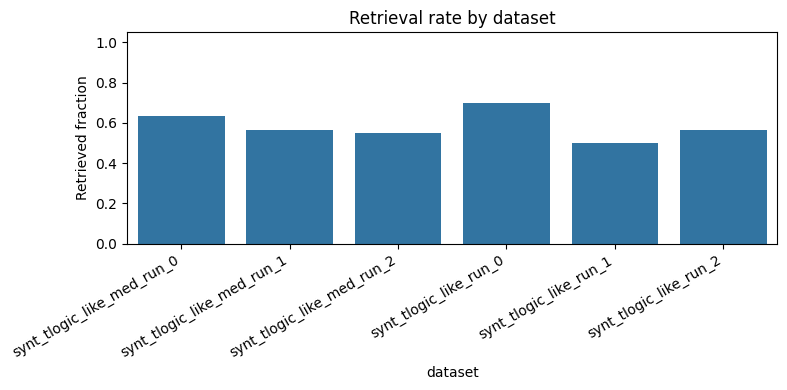

In [24]:
# Retrieval rate by dataset
plt.figure(figsize=(8,4))
sns.barplot(data=retrieval_rate, x='dataset', y='retrieval_rate')
plt.title('Retrieval rate by dataset')
plt.ylim(0, 1.05)
plt.ylabel('Retrieved fraction')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

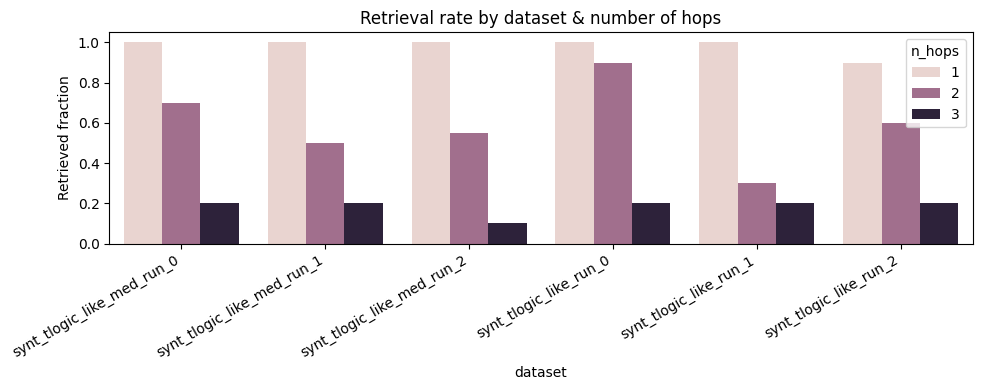

In [25]:
# Retrieval rate by dataset & n_hops
plt.figure(figsize=(10,4))
sns.barplot(data=retrieval_rate_hops, x='dataset', y='retrieval_rate', hue='n_hops')
plt.title('Retrieval rate by dataset & number of hops')
plt.ylim(0, 1.05)
plt.ylabel('Retrieved fraction')
plt.xticks(rotation=30, ha='right')
plt.legend(title='n_hops')
plt.tight_layout()
plt.show()

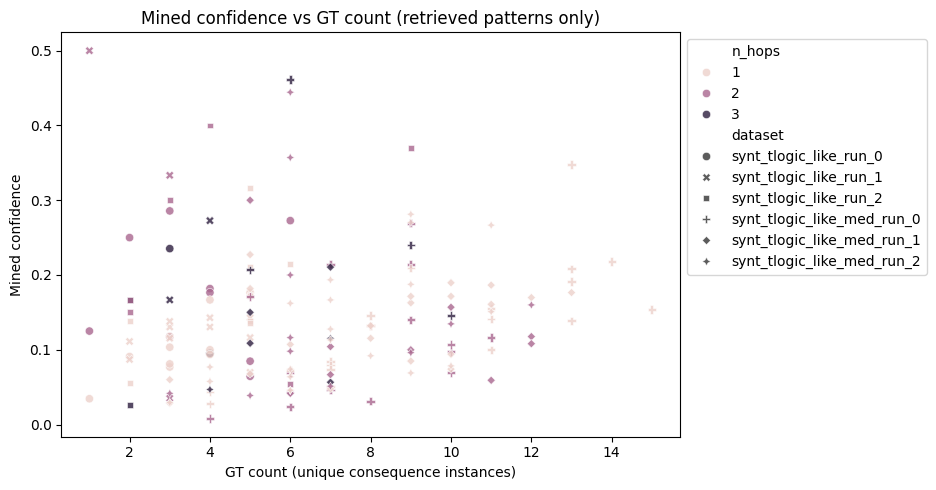

In [46]:
# Confidence vs ground-truth count (retrieved only)
if 'mined_confidence' in df_all.columns:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_all[df_all['retrieved']], x='gt_count', y='mined_confidence',
                    hue='n_hops', style='dataset', alpha=0.8)
    plt.title('Mined confidence vs GT count (retrieved patterns only)')
    plt.xlabel('GT count (unique consequence instances)')
    plt.ylabel('Mined confidence')
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1, 1))
    plt.show()

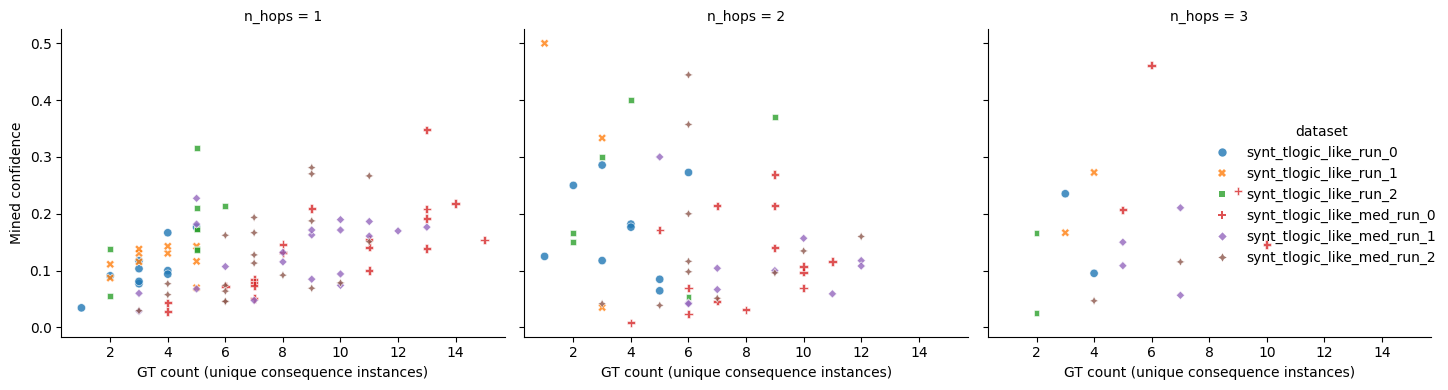

In [40]:
# Faceted: confidence vs GT count (retrieved only), split by n_hops
if {'mined_confidence', 'gt_count', 'n_hops', 'retrieved'}.issubset(df_all.columns):
    df_plot = df_all[(df_all['retrieved']) & (df_all['n_hops'].isin([1, 2, 3]))].copy()

    g = sns.relplot(
        data=df_plot,
        x='gt_count',
        y='mined_confidence',
        col='n_hops',
        col_order=[1, 2, 3],
        kind='scatter',
        hue='dataset',
        style='dataset',
        alpha=0.8,
        height=4,
        aspect=1,
        facet_kws={'sharex': True, 'sharey': True}
    )

    g.set_axis_labels("GT count (unique consequence instances)", "Mined confidence")
    g.set_titles("n_hops = {col_name}")
    g.add_legend()
    plt.tight_layout()
    plt.show()

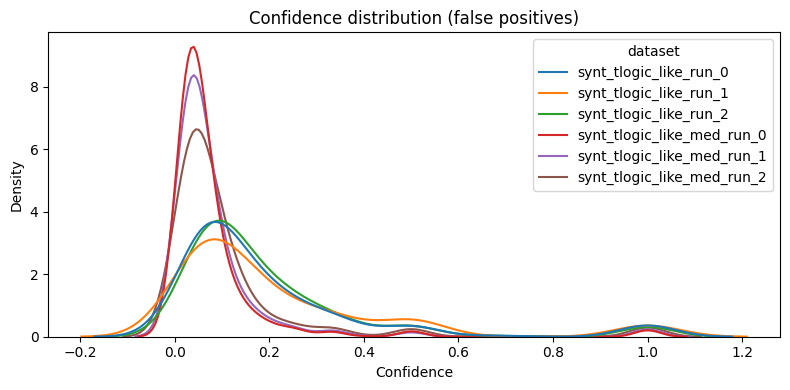

In [31]:
# False positives: confidence distribution
if not df_fp_all.empty and 'confidence' in df_fp_all.columns:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df_fp_all, x='confidence', hue='dataset', common_norm=False)
    plt.title('Confidence distribution (false positives)')
    plt.xlabel('Confidence')
    # plt.yscale('log')
    plt.tight_layout()
    plt.show()

In [32]:
# Top false positives by confidence (per dataset)
if not df_fp_all.empty and 'confidence' in df_fp_all.columns:
    topk = (df_fp_all[
        df_fp_all['confidence'] >= .2
    ].sort_values(['dataset','support'], ascending=[True, False])
                   .groupby('dataset')
                   .head(10))
    display(topk[['dataset','n_hops','canonical_key','confidence','count','support']])

,dataset,n_hops,canonical_key,confidence,count,support
2167,synt_tlogic_like_med_run_0,3,e1-1-e2 & e1-1-e2 & e2-6-e3 -> e2-9-e3,0.200000,10,50
2024,synt_tlogic_like_med_run_0,3,e1-0-e2 & e1-14-e3 & e4-18-e3 -> e4-6-e2,0.210526,4,19
2020,synt_tlogic_like_med_run_0,3,e1-0-e2 & e1-12-e3 & e4-9-e3 -> e2-1-e4,0.200000,3,15
4076,synt_tlogic_like_med_run_0,3,e1-5-e2 & e1-18-e3 & e3-13-e4 -> e4-9-e2,0.200000,3,15
3420,synt_tlogic_like_med_run_0,3,e1-18-e2 & e3-16-e1 & e4-15-e3 -> e2-17-e4,0.214286,3,14
3495,synt_tlogic_like_med_run_0,3,e1-19-e2 & e1-5-e3 & e3-1-e4 -> e2-15-e4,0.214286,3,14
3995,synt_tlogic_like_med_run_0,2,e1-4-e2 & e2-8-e3 -> e1-10-e3,0.307692,4,13
4584,synt_tlogic_like_med_run_0,3,e1-8-e2 & e2-17-e1 & e1-6-e3 -> e1-9-e3,0.250000,3,12
2509,synt_tlogic_like_med_run_0,3,e1-11-e2 & e3-18-e2 & e4-6-e3 -> e4-0-e1,0.272727,3,11
2706,synt_tlogic_like_med_run_0,3,e1-12-e2 & e3-4-e2 & e3-18-e4 -> e4-8-e1,0.200000,2,10


TODO Look at false positives. Are these subsequences of ground truth patterns or otherwise related to the ground-truth patterns (supersequences or compositions)?